In [15]:
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

from numpy.random import dirichlet


In [2]:
sns.set_theme(style="whitegrid")

In [3]:
conversions_A = 120
total_A = 1500

conversions_B = 145
total_B = 1500

In [4]:
with pm.Model() as advanced_ab_model:

    p_A = pm.Beta(
        "p_A",
        alpha=1,
        beta=1
    )

    p_B = pm.Beta(
        "p_B",
        alpha=1,
        beta=1
    )

    obs_A = pm.Binomial(
        "obs_A",
        n=total_A,
        p=p_A,
        observed=conversions_A
    )

    obs_B = pm.Binomial(
        "obs_B",
        n=total_B,
        p=p_B,
        observed=conversions_B
    )

    delta = pm.Deterministic(
        "delta",
        p_B - p_A
    )

    trace_advanced = pm.sample(
        draws=4000,
        tune=3000,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_A, p_B]


Output()

Sampling 4 chains for 3_000 tune and 4_000 draw iterations (12_000 + 16_000 draws total) took 2 seconds.


In [5]:
az.summary(
    trace_advanced,
    var_names=["p_A", "p_B", "delta"]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_A,0.081,0.007,0.068,0.094,0.0,0.0,10102.0,9754.0,1.0
p_B,0.097,0.008,0.082,0.111,0.0,0.0,11510.0,9769.0,1.0
delta,0.017,0.011,-0.003,0.037,0.0,0.0,10453.0,8958.0,1.0


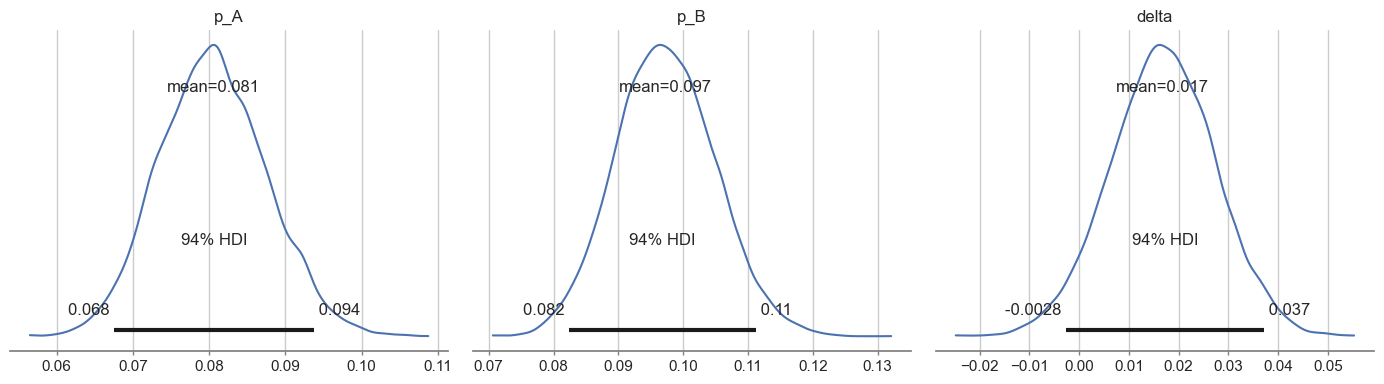

In [6]:
az.plot_posterior(
    trace_advanced,
    var_names=["p_A", "p_B", "delta"],
    figsize=(14, 4)
)

plt.tight_layout();

In [7]:
delta_samples = (
    trace_advanced.posterior["delta"]
    .stack(sample=("chain", "draw"))
    .values
)

prob_B_better = np.mean(
    delta_samples > 0
)

print(f"P(B > A) = {prob_B_better:.4f}")

P(B > A) = 0.9422


In [8]:
loss_A = np.mean(
    np.maximum(delta_samples, 0)
)

loss_B = np.mean(
    np.maximum(-delta_samples, 0)
)

In [9]:
print(
    f"Expected loss for choosing A: "
    f"{loss_A:.5f}"
)

print(
    f"Expected loss for choosing B: "
    f"{loss_B:.5f}"
)

Expected loss for choosing A: 0.01703
Expected loss for choosing B: 0.00027


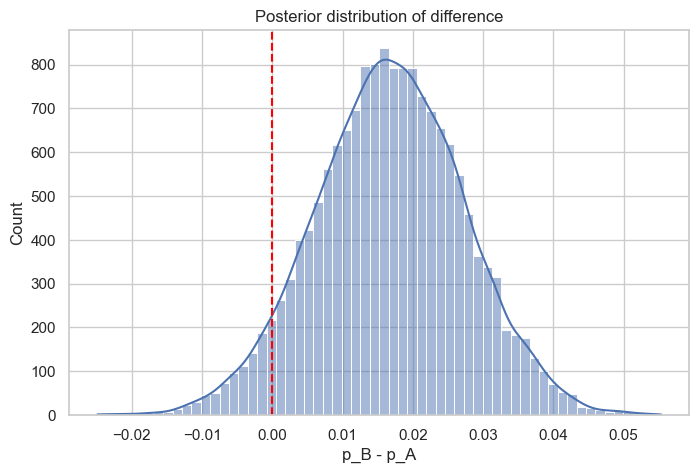

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    delta_samples,
    bins=60,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("p_B - p_A")

plt.title(
    "Posterior distribution of difference"
);

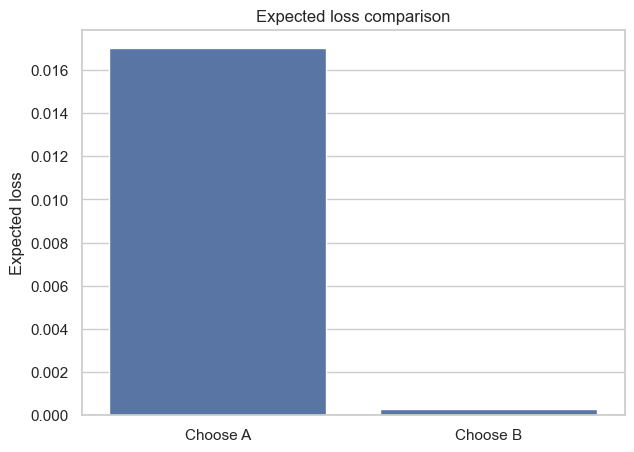

In [11]:
plt.figure(figsize=(7, 5))

losses = [loss_A, loss_B]

labels = [
    "Choose A",
    "Choose B"
]

sns.barplot(
    x=labels,
    y=losses
)

plt.ylabel("Expected loss")

plt.title(
    "Expected loss comparison"
);

In [12]:
if loss_B < loss_A:
    print(
        "Вариант B предпочтительнее."
    )
else:
    print(
        "Вариант A предпочтительнее."
    )

Вариант B предпочтительнее.


In [16]:
N = 1000

N_79 = 10
N_49 = 46
N_25 = 80
N_0 = N - (N_79 + N_49 + N_25)

observations = np.array([N_79, N_49, N_25, N_0])

observations

array([ 10,  46,  80, 864])

In [17]:
prior_parameters = np.array([1, 1, 1, 1])

posterior_parameters = prior_parameters + observations

posterior_samples = dirichlet(
    posterior_parameters,
    size=10000
)

posterior_samples[:5]

array([[0.00708049, 0.05010262, 0.07494252, 0.86787437],
       [0.00892252, 0.05959651, 0.08447525, 0.84700571],
       [0.01483693, 0.03990316, 0.09024216, 0.85501775],
       [0.01180536, 0.0595213 , 0.08279842, 0.84587492],
       [0.01392488, 0.05425155, 0.08745652, 0.84436705]])

In [18]:
N = 1000

N_79 = 10
N_49 = 46
N_25 = 80
N_0 = N - (N_79 + N_49 + N_25)

observations = np.array([N_79, N_49, N_25, N_0])

observations

array([ 10,  46,  80, 864])

In [19]:
prior_parameters = np.array([1, 1, 1, 1])

posterior_parameters = prior_parameters + observations

posterior_samples = dirichlet(
    posterior_parameters,
    size=10000
)

posterior_samples[:5]

array([[0.00783122, 0.04380629, 0.09422786, 0.85413463],
       [0.01249682, 0.05203927, 0.0772407 , 0.85822322],
       [0.00874873, 0.04396429, 0.07032108, 0.8769659 ],
       [0.00841801, 0.04498506, 0.07891789, 0.86767904],
       [0.01130454, 0.04926573, 0.07407027, 0.86535946]])

In [20]:
posterior_samples[0], posterior_samples[0].sum()

(array([0.00783122, 0.04380629, 0.09422786, 0.85413463]), np.float64(1.0))

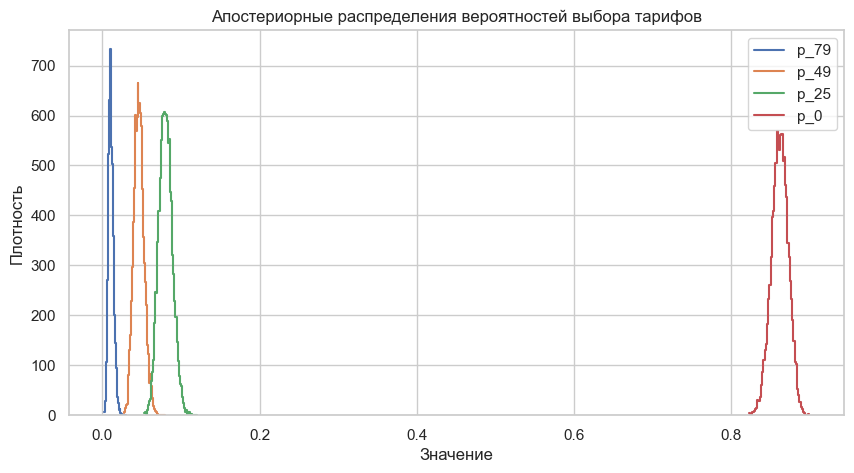

In [25]:
labels = ["p_79", "p_49", "p_25", "p_0"]

plt.figure(figsize=(10, 5))

for i, label in enumerate(labels):
    sns.histplot(
        posterior_samples[:, i],
        bins=50,
        element="step",
        fill=False,
        label=label
    )

plt.xlabel("Значение")
plt.ylabel("Плотность")
plt.title("Апостериорные распределения вероятностей выбора тарифов")
plt.legend();

In [22]:
def expected_revenue(P):
    return (
        79 * P[:, 0]
        + 49 * P[:, 1]
        + 25 * P[:, 2]
        + 0 * P[:, 3]
    )

In [23]:
posterior_expected_revenue = expected_revenue(posterior_samples)

posterior_expected_revenue.mean()

np.float64(5.170192124836146)

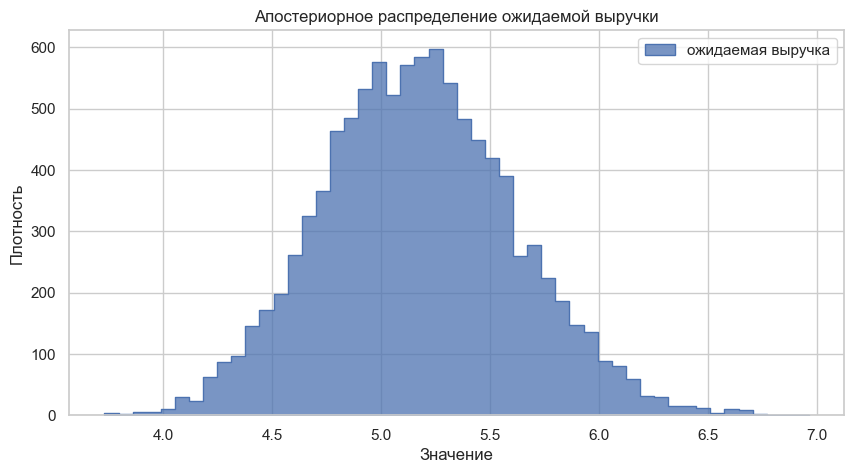

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    posterior_expected_revenue,
    bins=50,
    element="step",
    fill=True,
    label="ожидаемая выручка"
)

plt.xlabel("Значение")
plt.ylabel("Плотность")
plt.title("Апостериорное распределение ожидаемой выручки")
plt.legend();